### Regresión Lineal: Coste de un incidente de seguridad
- En este ejercicio se explican los fundamentos básicos de la regresión lineal aplicada a un caso de uso sencillo relacionado con la Ciberseguridad.

- El ejercicio consiste en predecir el coste de un incidente de seguridad en base al número de equipos que se han visto afectados. El conjunto de datos
es generado de manera aleatoria.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

In [17]:
#Generacion del conjunto de datos aleatoriamente
x = 2 * np.random.rand(100,1) #100 filas, 1 columna.
y = 4 + 3 + x + np.random.rand(100,1) 
len(x)

100

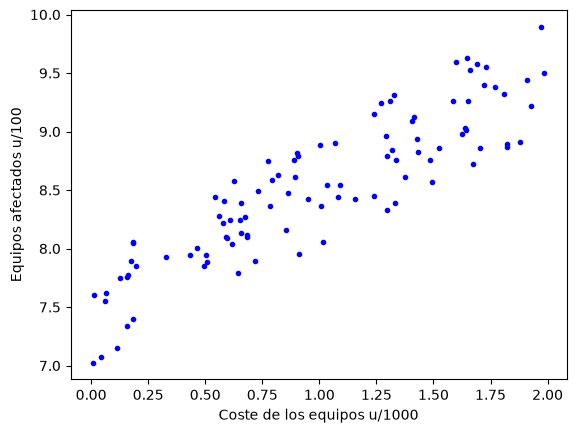

In [18]:
plt.plot(x,y,'b.')
plt.ylabel('Equipos afectados u/100')
plt.xlabel('Coste de los equipos u/1000')
plt.show()

In [19]:
#Convertir valores a un diccionario y hacerlos un dataframe 
data = {'Equipos afectados': x.flatten(), 'Coste de los equipos': y.flatten()}
df = pd.DataFrame(data)
df.head()

,Equipos afectados,Coste de los equipos
0,1.771525,9.378464
1,0.863578,8.479140
2,1.653096,9.258404
3,0.909664,7.956223
4,0.593366,8.091365


In [20]:
#Escalar el numero de equipos afectados
df['Equipos afectados'] = df['Equipos afectados'] * 1000
df['Equipos afectados'] = df['Equipos afectados'].astype('int')

#Escalar numero de equipos afectados 
df['Coste de los equipos'] = df['Coste de los equipos'] * 1000
df['Coste de los equipos'] = df['Coste de los equipos'].astype('int')

df.head()

,Equipos afectados,Coste de los equipos
0,1771,9378
1,863,8479
2,1653,9258
3,909,7956
4,593,8091


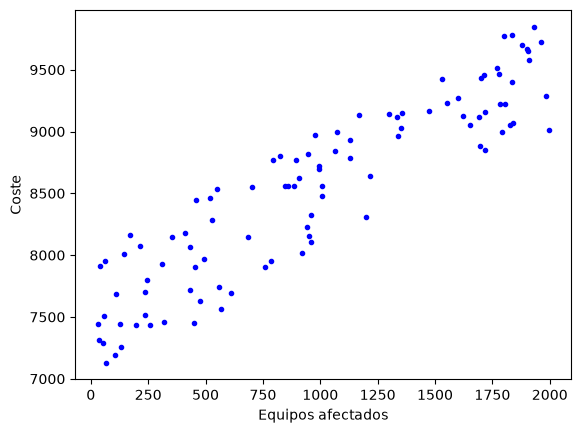

In [41]:
plt.plot(df['Equipos afectados'],df['Coste de los equipos'], 'b.')
plt.xlabel('Equipos afectados')
plt.ylabel('Coste')
plt.show()

# Contruccion del modelo

In [21]:
lin_reg = LinearRegression()
lin_reg.fit(df['Equipos afectados'].values.reshape(-1,1), df['Coste de los equipos'].values)#Recibe valores de entrada y de salida 


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.99]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7542
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5607.28]


In [22]:
#Theta 0
lin_reg.intercept_

np.float64(7542.45723595482)

In [23]:
#Theta 1
lin_reg.coef_

array([0.98551502])

In [29]:
#Prediccion del valor minimo y maximo del conjunto de datos
x_min_max = np.array([ [df['Equipos afectados'].min()] , [df['Equipos afectados'].max()] ])
y_train_predict = lin_reg.predict(x_min_max)

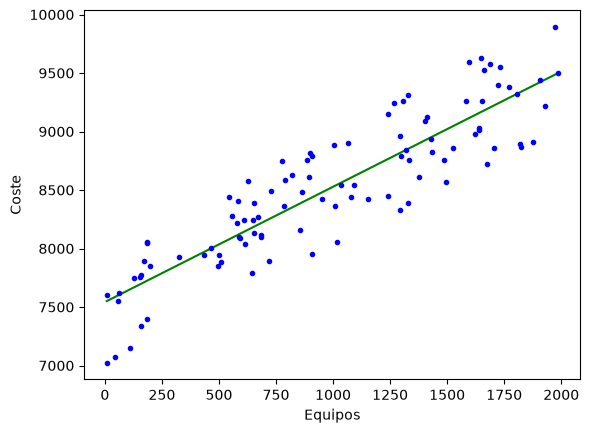

In [32]:
#Representacion grafica 
plt.plot(x_min_max, y_train_predict, 'g-')
plt.plot(df['Equipos afectados'], df['Coste de los equipos'], 'b.')
plt.ylabel('Coste')
plt.xlabel('Equipos')
plt.show()